In [16]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk
import numpy as np
import netket as nk
import jax
import jax.numpy as jnp
import jax.tree_util as tree
import matplotlib.pyplot as plt
import optax
from flax import nnx
from flax import linen as nn
from netket.operator import AbstractOperator
from netket.experimental.observable import Renyi2EntanglementEntropy
from tqdm import tqdm
from netket.jax import jacobian
from itertools import product

In [17]:
# Definimos el espacio en el que vamos a trabajar
from netket.hilbert import Spin, DiscreteHilbert, TensorHilbert
N = 2
N_ancilla = 2

# Sistema principal: N espines 1/2
# Ancilla: N_ancilla espines 1/2
hi_system = nk.hilbert.Spin(s=1/2, N=N)
# Espacio total = spin ⊗ ancilla
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [18]:
# Importamos las matrices de Pauli y definimos el Hamiltoniano  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    # Estos operadores automáticamente son σ_x^i ⊗ I_R
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

In [19]:
# Función que emplea el swap trick para calcular la entropía de entrelazamiento
def renyi2_entropy_sampled(vstate, N, subsystem_sites, n_samples, key=0, debug=False):
    """
    Estima la entropía de entrelazamiento de Rényi-2 (S₂) mediante muestreo Monte Carlo
    usando el *swap trick*.

    Calcula:
        S₂ = -log( ⟨SWAP⟩ )

    donde ⟨SWAP⟩ es el valor esperado del operador swap que intercambia el subsistema
    `subsystem_sites` entre dos copias independientes del estado |ψ⟩.

    El valor esperado se estima estocásticamente a partir de muestras generadas con
    `vstate.sample`.

    Args:
        vstate : netket.vqs.MCState
            Estado variacional de NetKet que representa la función de onda |ψ⟩.

        N : int
            Número total de grados de libertad (spins/qubits).
            (Nota: actualmente no se usa explícitamente dentro de la función).

        subsystem_sites : array-like
            Índices de los sitios que definen el subsistema A.
            La entropía se calcula entre A y su complemento.

        n_samples : int
            Número de muestras Monte Carlo usadas para estimar ⟨SWAP⟩.
            Se generan 2 * n_samples configuraciones en total.

        key : int, optional
            Semilla para la permutación aleatoria de las muestras (JAX PRNG key).
            Default: 0.

        debug : bool, optional
            Si True, imprime información detallada sobre:
            - muestras generadas
            - configuraciones intercambiadas
            - valores medios de log |ψ|
            - estimación de ⟨SWAP⟩

    Returns:
       S2 : jax.numpy.DeviceArray
        Estimación Monte Carlo de la entropía de Rényi-2 del subsistema definido
        por `subsystem_sites`.

    """

    # Asegurar que subsystem_sites es un array de enteros
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestras
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    if debug:
      print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
      # print(f"All samples: " {all_samples})
      print(f"Samples1: {samples1}")
      print(f"Samples2: {samples2}")

    # Calcular el complementario
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)


    # Intercambio de subsistemas
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    if debug:
      print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
      print(f"Swapped1: {swapped1}")
      print(f"Swapped2: {swapped2}")

    # Log amplitudes de las configuraciones originales y permutadas
    log_psi_orig1 = vstate.log_value(samples1)
    log_psi_orig2 = vstate.log_value(samples2)
    log_psi_swap1 = vstate.log_value(swapped1)
    log_psi_swap2 = vstate.log_value(swapped2)
    if debug:
      # print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)), "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)))
      print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)).item(),  "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)).item())
      print("log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap1)).item(), "log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap2)).item())

    # ⟨SWAP⟩ = ⟨ψ(x')ψ(y') / [ψ(x)ψ(y)]⟩
    swap_ratio = jnp.exp((log_psi_swap1 + log_psi_swap2) - (log_psi_orig1 + log_psi_orig2))
    swap_exp = jnp.mean(swap_ratio)
    if debug:
      jax.debug.print("swap ratio = {}", jnp.round(swap_ratio, 4))
      print(f"⟨SWAP⟩ = {swap_exp.item()}")

    # Entropía de Rényi 2
    S2 = -jnp.log(jnp.abs(swap_exp))
    return S2

def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma exadta usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente, este ultimo utilizando
    el gradiente de la log-amplitud de las samples
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO
    # ============================================================
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) CREACIÓN DE CONFIGURACIONES SWAP
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    if debug:
        print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
    
    # ============================================================
    # 3) LOG-AMPLITUDES
    # ============================================================
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    if debug:
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
    
    # ============================================================
    # 4) RATIO SWAP Y ENTROPÍA S₂
    # ============================================================
    R = jnp.exp((log_s1 + log_s2) - (log_o1 + log_o2))  
    R_mean = jnp.mean(R)
    S2 = -jnp.log(jnp.abs(R_mean))
    
    if debug:
        print(f"⟨SWAP⟩ = {R_mean:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ============================================================
    # 5) GRADIENTES (O_θ = ∂_θ log ψ)
    # ============================================================
    O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)  
    
    O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    # ============================================================
    # 6) ΔO = O(x') + O(y') - O(x) - O(y)
    # ============================================================
    DeltaO = jax.tree_util.tree_map(
        lambda s1, s2, o1, o2: s1 + s2 - o1 - o2,
        O_s1, O_s2, O_o1, O_o2
    )
    
    # ============================================================
    # 7) ⟨R * ΔO⟩ (promedio ponderado por R)
    # ============================================================
    def weighted_average(leaf):
        """
        leaf: array de forma (n_samples, *param_shape)
        Calcula ⟨R * leaf⟩ promediando sobre axis=0
        """
        # Expandir R para broadcasting: (n_samples, 1, 1, ...)
        expanded_R = R.reshape(-1, *([1] * (leaf.ndim - 1)))
        return jnp.mean(expanded_R * leaf, axis=0)
    
    numerator = jax.tree_util.tree_map(weighted_average, DeltaO)
    
    # ============================================================
    # 8) ∂θ S₂ = - ⟨R ΔO⟩ / ⟨R⟩
    # ============================================================
    grad_S2 = jax.tree_util.tree_map(lambda x: -x / R_mean, numerator)
    
    if debug:
        # Calcular norma del gradiente para debug
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente de forma similar a "renyi2_entropy_and_grad_sampled"
    pero numéricamente estable (aún no funciona bien del todo)
    
    Usa logsumexp y diferenciación automática para evitar overflow/underflow.
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO - Dos conjuntos independientes
    # ============================================================
    rng = jax.random.PRNGKey(key)
    rng1, rng2 = jax.random.split(rng)
    
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    
    # Asegurar mismo tamaño
    M = min(samples1.shape[0], samples2.shape[0])
    samples1 = samples1[:M]
    samples2 = samples2[:M]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) PREPARAR SITIOS
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    # Precomputar configuraciones swapeadas (no dependen de params)
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], 
                                samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], 
                                samples2[:, complement_sites]], axis=1)
    
    # ============================================================
    # 3) FUNCIÓN PARA CALCULAR ln P (PURITY) - VERSIÓN EFICIENTE
    # ============================================================
    def log_psi_fn(params, samples):
        """Helper para evaluar log ψ sin crear vstate temporal"""
        return vstate.model.apply(
            {'params': params}, 
            samples,
            mutable=False
        )
    
    def lnP_estimator(params):
        """
        Calcula ln P_A de forma numéricamente estable usando logsumexp.
        
        P_A = ⟨Q⟩ donde Q_k = |ψ(α',β)|² |ψ(α,β')|² / (|ψ(α,β)|² |ψ(α',β')|²)
        
        ln P_A = logsumexp(log Q_k) - ln M
        """
        # Log-amplitudes evaluadas directamente con el modelo
        log_o1 = log_psi_fn(params, samples1)
        log_o2 = log_psi_fn(params, samples2)
        log_s1 = log_psi_fn(params, swapped1)
        log_s2 = log_psi_fn(params, swapped2)
        
        # log Q_k para cada par de muestras k
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        
        # logsumexp automáticamente maneja la estabilidad numérica
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(M)
        
        # Tomamos la parte real para asegurar que sea un número real
        return lnP.real
    
    # ============================================================
    # 4) CALCULAR S2 Y SU GRADIENTE
    # ============================================================
    # Primero calculamos S2
    lnP = lnP_estimator(vstate.parameters)
    S2 = -lnP  # S2 = -ln(P)
    
    # Gradiente usando diferenciación automática de JAX
    # JAX automáticamente calcula los pesos softmax al diferenciar logsumexp
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters)
    
    # Convertir gradiente de ln P a gradiente de S2
    # ∂S2/∂θ = -∂(ln P)/∂θ
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    # ============================================================
    # 5) DEBUG INFO
    # ============================================================
    if debug:
        # Calcular algunas métricas para verificación
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)
        
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
        
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        print(f"mean log Q: {jnp.mean(log_q_loc):.6f}")
        print(f"std log Q: {jnp.std(log_q_loc):.6f}")
        print(f"ln P = {lnP:.6f}")
        print(f"S₂ = {S2:.6f}")
        
        # Calcular norma del gradiente
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_grad_only_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula SOLO el gradiente de S2.
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    N = vstate.hilbert.size
    
    # Draw two independent replica batches
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    
    # M = min(samples1.shape[0], samples2.shape[0])
    # samples1 = samples1[:M]
    # samples2 = samples2[:M]
    
    def lnP_estimator(params, sigma1, sigma2):
        # Split each replica into A and B
        alpha = sigma1[:, subsystem_sites]
        alpha_p = sigma2[:, subsystem_sites]
        
        all_sites = jnp.arange(N)
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
        beta = sigma1[:, complement_sites]
        beta_p = sigma2[:, complement_sites]
        
        # Swapped configurations
        sigma_a_p_b = jnp.concatenate([alpha_p, beta], axis=-1)
        sigma_a_b_p = jnp.concatenate([alpha, beta_p], axis=-1)
        
        def logpsi_batch(p, σ):
            return vstate.model.apply({"params": p}, σ)
        
        logpsi_ab = logpsi_batch(params, sigma1)
        logpsi_a_p_b_p = logpsi_batch(params, sigma2)
        logpsi_a_p_b = logpsi_batch(params, sigma_a_p_b)
        logpsi_a_b_p = logpsi_batch(params, sigma_a_b_p)
        
        # Factor 2.0 para log|ψ|²
        log_q_loc = 2.0 * (
            (logpsi_a_p_b.real + logpsi_a_b_p.real) - 
            (logpsi_ab.real + logpsi_a_p_b_p.real)
        )
        
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(log_q_loc.shape[0])
        return lnP
    
    # Gradient of ln P (no S2 computed)
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters, samples1, samples2)
    
    # Convert to gradient of S2
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    if debug:
        grad_dense, _ = ravel_pytree(grad_S2)
        grad_norm = jnp.linalg.norm(grad_dense)
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return grad_S2

# Utilizamos Jax para calcular el gradiente de la entropía
def renyi2_value_and_grad(vstate, N, subsystem_sites, n_samples=1000, key=0, debug=False):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada mediante el swap trick
    en función de los parámetros variacionales del estado |ψ⟩,
    '''
    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(vstate.sampler, vstate.model,
                                  n_samples=vstate.n_samples)
        vstate_tmp.parameters = params
        S2 = renyi2_entropy_sampled(vstate_tmp, N, subsystem_sites, n_samples, key, debug)
        return S2

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    if debug:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad)[0])
        print(f"S₂={S2_val}, ∇S₂={grad_norm}")

    return S2_val, S2_grad

def renyi2_value_and_grad2(vstate, hilbert, partition, n_samples):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada la implementación de NetKet
    en función de los parámetros variacionales del estado |ψ⟩,
    '''

    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(
        hilbert, partition=partition
    )

    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(
            sampler=vstate.sampler,
            model=vstate.model,
            n_samples=n_samples,
        )
        vstate_tmp.parameters = params
        return vstate_tmp.expect(S2_obs).mean.real

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2_val, S2_grad

In [22]:
#Model con simetría Z2
REAL_DTYPE = jnp.asarray(1.0).dtype
from typing import Callable, Sequence
import jax.typing as jt
class MultiLayerPerceptron(nn.Module):
    """Flax module for a Multi-layer perceptron architecture with normalization.

    Args:
        layer_widths: Sequence of integers that define both the number of layers
            and their widths.
        activation_funcion: The activation function that will be applied after
            each dense layer.
        kernel_init: Function to initialize the trainable parameters.

    Returns:
        A jax array with the output of the net.
    """

    layer_widths: Sequence[int]
    activation_function: Callable = nn.swish
    kernel_init: Callable = nn.initializers.lecun_normal()

    @nn.compact
    def __call__(self, x) -> jt.ArrayLike:
        for w in self.layer_widths:
            # We cannot use LayerNorm when the output has size 1, since
            # that would destroy the data.
            if w == 1:
                normalizer = lambda x: x
            else:
                normalizer = nn.LayerNorm(param_dtype=REAL_DTYPE)
            x = self.activation_function(
                normalizer(
                    nn.Dense(
                        w,
                        kernel_init=self.kernel_init,
                        param_dtype=REAL_DTYPE,
                    )(x)
                )
            )
        return x
    
class RBM_Z2(nn.Module):

    alpha: int = 1
    trivial_Z2: bool = False  # True → simetría (ψ(x)=ψ(-x)), False → antisimetría (ψ(x)=-ψ(-x))

    @nn.compact
    def __call__(self, x):
        # Definimos la RBM
        # worker = nk.models.RBM(alpha=self.alpha, param_dtype=float)
        worker = MultiLayerPerceptron(layer_widths=[8,16,8,1])
        # worker = nk.models.ARNNDense(
            # hilbert= nk.hilbert.Spin(s=1/2, N=N+N_ancilla),
            # layers=2,           # 2 capas ocultas
            # features=16,        # 16 neuronas por capa
        # )

        # Calculamos la log-amplitud para x y -x
        output_x = jnp.atleast_1d(worker(x))
        output_inv_x = jnp.atleast_1d(worker(-x))

        # Apilamos las dos
        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        # Combinamos según el tipo de simetría
        if self.trivial_Z2:
            # Invariante (simétrica)
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            # Antisimétrica (cambia de signo)
            b = jnp.array([1.0, -1.0])[:, None]   #b es el coeficiente que precede a la exponencial. Por defecto = 1.0
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res

Step 0: S₂(SWAP)=0.012793, S₂(NK)=0.012343, |∇S₂| = 0.011652
Step 20: S₂(SWAP)=0.453102, S₂(NK)=0.416588, |∇S₂| = 0.053427
Step 40: S₂(SWAP)=0.694752, S₂(NK)=0.699718, |∇S₂| = 0.010132
Step 60: S₂(SWAP)=0.687512, S₂(NK)=0.689764, |∇S₂| = 0.000342
Step 80: S₂(SWAP)=0.690747, S₂(NK)=0.686746, |∇S₂| = 0.000121
Step 100: S₂(SWAP)=0.687177, S₂(NK)=0.687706, |∇S₂| = 0.001109
Step 120: S₂(SWAP)=0.694749, S₂(NK)=0.680032, |∇S₂| = 0.000021
Step 140: S₂(SWAP)=0.711316, S₂(NK)=0.712135, |∇S₂| = 0.000057
Step 160: S₂(SWAP)=0.702802, S₂(NK)=0.691553, |∇S₂| = 0.000077
Step 180: S₂(SWAP)=0.691749, S₂(NK)=0.681838, |∇S₂| = 0.000003
Step 200: S₂(SWAP)=0.700772, S₂(NK)=0.700779, |∇S₂| = 0.000023
Step 220: S₂(SWAP)=0.677275, S₂(NK)=0.674523, |∇S₂| = 0.000011
Step 240: S₂(SWAP)=0.685189, S₂(NK)=0.699960, |∇S₂| = 0.000044
Step 260: S₂(SWAP)=0.711313, S₂(NK)=0.696340, |∇S₂| = 0.000004
Step 280: S₂(SWAP)=0.701180, S₂(NK)=0.688356, |∇S₂| = 0.000001
Step 300: S₂(SWAP)=0.708465, S₂(NK)=0.686359, |∇S₂| = 0.00000

<function matplotlib.pyplot.show(close=None, block=None)>

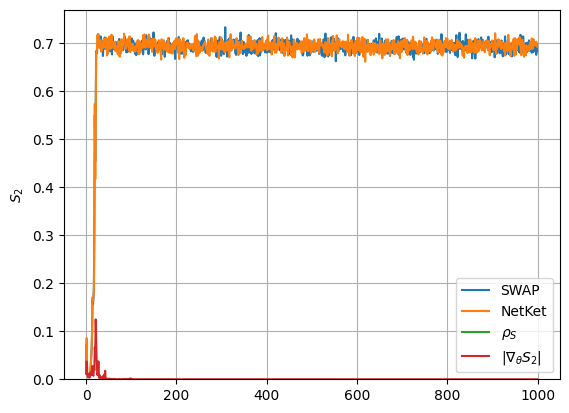

In [23]:
#Comprobar que la derivada del gradiente funciona
#Se busca el estado que maximiza S₂, en nuestro caso max(S₂)=ln(4)

partition = list(range(N))  
# g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
# sampler = nk.sampler.MetropolisLocal(hi_extended)
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=20000)
vstate.init_parameters
# optimizer = optax.sgd(learning_rate=0.8, momentum=0.9)
optimizer = optax.adam(learning_rate=optax.schedules.linear_onecycle_schedule(1000, 0.5, 0.3, 0.85, 10, 100))
# optimizer = optax.adamw(learning_rate=0.1, weight_decay=1e-2)
opt_state = optimizer.init(vstate.parameters)

S2_history_swap = []
S2_history_nk = []
S2_history_trace = []
S2_grad_history= []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    S2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 10000, key=step)
    # S2_grad_2 = renyi2_grad_only_stable(vstate, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_stable(vstate, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_averaged(vstate, partition, 1008, step, 10)
    # S2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_value_and_grad2(vstate, hi_extended, partition, 200000)
    S2_nk = vstate.expect(S2_obs).mean.real*np.log(2)
    # S2_trace = renyi2_entropy_exact(vstate, partition)[0]
    S2_grad = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad_2)[0])
    
    S_grad = jax.tree_util.tree_map(
        lambda grad_S2:  - grad_S2,
        S2_grad_2
    )
    
    updates, opt_state = optimizer.update(S_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)

    S2_history_swap.append(S2)
    S2_history_nk.append(S2_nk)
    # S2_history_trace.append(S2_trace)
    S2_grad_history.append(S2_grad)
    
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(S_grad)[0])
        # print(f"Step {step}: S₂(SWAP)={S2:.6f}, S₂(NK)={S2_nk:.6f}, S₂(ρₛ)={S2_trace:.6f}, |∇S₂| = {S2_grad:.6f}")
        print(f"Step {step}: S₂(SWAP)={S2:.6f}, S₂(NK)={S2_nk:.6f}, |∇S₂| = {S2_grad:.6f}")

plt.plot(S2_history_swap, label="SWAP")
plt.plot(S2_history_nk, label="NetKet")
plt.plot(S2_history_trace, label=r"$\rho_S$")
plt.plot(S2_grad_history, label=r"$|\nabla_\theta S_2$|")
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

S₂(SWAP)=0.697586, S₂(NK)=0.693935, S₂(ρₛ)0.693147


<function matplotlib.pyplot.show(close=None, block=None)>

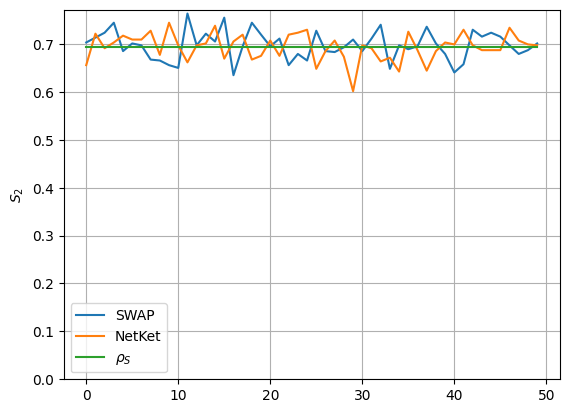

In [34]:
it = 50
entropy_1 = np.zeros(it)
entropy_2 = np.zeros(it)
entropy_3 = np.zeros(it)

for i in range(it):
    entropy_1[i] = renyi2_entropy_sampled(vstate, N, partition, 1000)
    entropy_2[i] = vstate.expect(S2_obs).mean.real*np.log(2)
    entropy_3[i] = renyi2_entropy_exact(vstate, partition)[0]

print(f"S₂(SWAP)={np.mean(entropy_1):.6f}, S₂(NK)={np.mean(entropy_2):.6f}, S₂(ρₛ){np.mean(entropy_3):.6f}")

plt.plot(entropy_1, label="SWAP")
plt.plot(entropy_2, label="NetKet")
plt.plot(entropy_3, label=r"$\rho_S$")
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

In [14]:
state_vector = vstate.to_array()
# print("Vector de estado completo:")
# print(state_vector)

# Obtener estados individuales con sus amplitudes
basis_states = hi_extended.all_states()
for i, state in enumerate(basis_states):
    amplitude = state_vector[i]
#     print(f"Estado {state}: {amplitude:.3f}")

# Calcular probabilidades
probabilities = jnp.abs(state_vector)**2
for i, state in enumerate(basis_states):
    print(f"P(|{state}⟩) = {probabilities[i]:.3f}")

prob00= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==-1 and state[1]==-1)
print(f"\nP(|-1-1⟩): {prob00:.3f}")
prob11= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==1 and state[1]==1)
print(f"\nP(|11⟩): {prob11:.3f}")
p01= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==-1 and state[1]==1))
print(f"\nP(|-11⟩): {p01:.3f}")
p10= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==1 and state[1]==-1))
print(f"\nP(|1-1⟩): {p10:.3f}")

P(|[1 1 1 1]⟩) = 0.000
P(|[ 1  1  1 -1]⟩) = 0.000
P(|[ 1  1 -1  1]⟩) = 0.000
P(|[ 1  1 -1 -1]⟩) = 0.012
P(|[ 1 -1  1  1]⟩) = 0.488
P(|[ 1 -1  1 -1]⟩) = 0.000
P(|[ 1 -1 -1  1]⟩) = 0.000
P(|[ 1 -1 -1 -1]⟩) = 0.000
P(|[-1  1  1  1]⟩) = 0.000
P(|[-1  1  1 -1]⟩) = 0.000
P(|[-1  1 -1  1]⟩) = 0.000
P(|[-1  1 -1 -1]⟩) = 0.488
P(|[-1 -1  1  1]⟩) = 0.012
P(|[-1 -1  1 -1]⟩) = 0.000
P(|[-1 -1 -1  1]⟩) = 0.000
P(|[-1 -1 -1 -1]⟩) = 0.000

P(|-1-1⟩): 0.012

P(|11⟩): 0.012

P(|-11⟩): 0.488

P(|1-1⟩): 0.488


In [27]:
#Minimizar F = <H> - TS₂ mediante descenso de gradiente

partition = list(range(N))  
S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

# Estado variacional
# g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
# sampler = nk.sampler.MetropolisLocal(hi_extended)
sampler = nk.sampler.ExactSampler(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)


energy_history = []
entropy_history = []
F_history = []
S_1_history = []
S_2_history = []

T = 2     # temperatura
n_steps = 300  # número de pasos de optimización
lr = 0.1    # learning rate


# for step in tqdm(range(n_steps)):
for step in tqdm(range(n_steps)):
    # Energía y gradiente
    E, E_grad = vstate.expect_and_grad(H_extended)
    # Entropía S₂ y su gradiente
    # S2 = vstate.expect(S2_obs)
    # S21_2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 1008, key=step)
    # S21, S2_grad = renyi2_value_and_grad2(vstate, hi_extended, partition, 1008)
    S21_2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 1008, key=step)
    S2_grad_modulus = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad_2)[0])

    # Free energy F = E - T*S₂
    F = E.mean.real - T * S21_2

    # ∇F = ∇E - T * ∇S₂
    F_grad = jax.tree_util.tree_map(lambda grad_E, grad_S2: grad_E - T * grad_S2,
                                   E_grad, S2_grad_2)

    energy_history.append(E.mean.real)
    # entropy_history.append(S2.mean.real)
    F_history.append(F)
    S_1_history.append(S21_2)
    # S_2_history.append(S2.mean.real)

    # Actualización parámetros
    new_params = jax.tree_util.tree_map(lambda x, y: x - lr * y, vstate.parameters, F_grad)
    vstate.parameters = new_params

    if (step) % 20 == 0:
        F_grad_modulus = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
        print(f"Step {step}: E = {E.mean.real:.6f}, S₂ = {S21_2:.6f}, F = {F:.6f}")
        print(f"         |∇E| = {jnp.linalg.norm(nk.jax.tree_ravel(E_grad)[0]):.6f}, |∇S₂| = {S2_grad_modulus:.6f}, |∇F| = {F_grad_modulus:.6f}")
        print(f"         S₂ netket = {vstate.expect(S2_obs).mean.real:.3f}, S₂ = {S21_2:.3f}")

# Resultados finales
final_energy = vstate.expect(H_extended).mean.real
final_entropy = renyi2_entropy_and_grad_sampled(vstate, partition, 2016, key=step)[0]
final_F = final_energy - T * final_entropy

print("\n=== RESULTADOS FINALES ===")
print(f"⟨H⟩ = {final_energy:.6f}")
print(f"S₂ = {final_entropy:.6f}")
print(f"F = {final_F:.6f}")

  0%|          | 0/300 [00:00<?, ?it/s]

  3%|▎         | 10/300 [00:00<00:05, 52.02it/s]

Step 0: E = -3.138991, S₂ = -0.000032, F = -3.138927
         |∇E| = 0.092852, |∇S₂| = 0.004016, |∇F| = 0.095718
         S₂ netket = -0.000, S₂ = -0.000


 12%|█▏        | 35/300 [00:00<00:03, 74.05it/s]

Step 20: E = -3.603370, S₂ = 0.002153, F = -3.607676
         |∇E| = 0.077251, |∇S₂| = 0.045113, |∇F| = 0.063571
         S₂ netket = 0.006, S₂ = 0.002


...

Step 260: E = -3.605308, S₂ = -0.000001, F = -3.605305
         |∇E| = 0.021200, |∇S₂| = 0.015428, |∇F| = 0.049888
         S₂ netket = -0.001, S₂ = -0.000


 99%|█████████▉| 297/300 [00:03<00:00, 91.69it/s]

Step 280: E = -3.606122, S₂ = 0.001660, F = -3.609442
         |∇E| = 0.052655, |∇S₂| = 0.057617, |∇F| = 0.079730
         S₂ netket = 0.000, S₂ = 0.002


100%|██████████| 300/300 [00:03<00:00, 80.89it/s]


=== RESULTADOS FINALES ===
⟨H⟩ = -3.605290
S₂ = 0.001087
F = -3.607463


In [ ]:
#Minimizar F = <H> - TS₂ mediante ADAM o SGD
partition = list(range(N))  
# Estado variacional
g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
# sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
# optimizer = optax.adam(learning_rate=0.003)
optimizer = optax.sgd(learning_rate=0.05)
opt_state = optimizer.init(vstate.parameters)

# ========== LOOP DE OPTIMIZACIÓN ==========
T = 2
energy_history = []
S2_history = []
F_history = []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    E, E_grad = vstate.expect_and_grad(H_extended)
    S21_2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 1008, key=step)
    # S21_2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 1008, key=step)
    # S21_2, S2_grad_2 = renyi2_value_and_grad2(vstate, hi_extended, partition, 1008)
    S21_22 = vstate.expect(S2_obs).mean
    # S21_22 = renyi2_entropy_sampled(vstate, N, partition, 1008, key=step)
    
    # 3. Combinar gradientes: ∇F = ∇E - T * ∇S₂
    F_grad = jax.tree_util.tree_map(
        lambda grad_E, grad_S2: grad_E - T * grad_S2,
        E_grad, S2_grad_2
    )
    
    # 4. Actualizar parámetros con Adam (optax)
    updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)
    
    # 5. Calcular free energy
    F = E.mean.real - T * S21_2
    
    # 6. Guardar historia
    energy_history.append(E.mean.real)
    S2_history.append(S21_2)
    F_history.append(F)
    
    # 7. Log cada 20 pasos
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
        print(f"Step {step}: E={E.mean.real:.6f}, S₂={S21_2:.6f}, S₂={S21_22:.6f}, F={F:.6f}, |∇F|={grad_norm:.6f}")

Step 0: E=-3.226312, S₂=0.000045, S₂=0.000028, F=-3.226401, |∇F|=0.184977
Step 20: E=-3.496153, S₂=-0.006035, S₂=-0.008546, F=-3.484083, |∇F|=0.900320
Step 40: E=-3.597852, S₂=0.016486, S₂=0.023381, F=-3.630824, |∇F|=0.027074
Step 60: E=-3.597720, S₂=0.023642, S₂=0.013128, F=-3.645004, |∇F|=0.250501
Step 80: E=-3.596730, S₂=0.012555, S₂=0.015357, F=-3.621840, |∇F|=0.189293
Step 100: E=-3.597977, S₂=0.022548, S₂=0.019416, F=-3.643072, |∇F|=0.126281
Step 120: E=-3.598017, S₂=0.016000, S₂=0.012796, F=-3.630017, |∇F|=0.036542
Step 140: E=-3.597470, S₂=0.014948, S₂=0.010755, F=-3.627366, |∇F|=0.231631
Step 160: E=-3.598199, S₂=0.022566, S₂=0.015393, F=-3.643330, |∇F|=0.126194
Step 180: E=-3.597333, S₂=0.020646, S₂=0.012924, F=-3.638625, |∇F|=0.114697
Step 200: E=-3.595169, S₂=0.012910, S₂=0.010004, F=-3.620990, |∇F|=0.200866
Step 220: E=-3.599140, S₂=0.013768, S₂=0.010868, F=-3.626676, |∇F|=0.053006
Step 240: E=-3.599772, S₂=0.017002, S₂=0.006921, F=-3.633776, |∇F|=0.168164
Step 260: E=-3.5

Temperaturas:   0%|          | 0/10 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
  Step 0: E=-2.9994, S₂=0.0000, S₂(NK)=0.0000, F=-2.9994, |∇F|=0.1461
  Step 50: E=-3.6026, S₂=-0.0000, S₂(NK)=0.0000, F=-3.6026, |∇F|=0.1668
  Step 100: E=-3.6055, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.6055, |∇F|=0.0092
  Step 150: E=-3.6056, S₂=0.0000, S₂(NK)=-0.0000, F=-3.6056, |∇F|=0.0002
  Step 200: E=-3.6056, S₂=0.0000, S₂(NK)=0.0000, F=-3.6056, |∇F|=0.0000
  Step 250: E=-3.6056, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.6056, |∇F|=0.0000
  Step 300: E=-3.6056, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.6056, |∇F|=0.0000
  Step 350: E=-3.6056, S₂=-0.0000, S₂(NK)=0.0000, F=-3.6056, |∇F|=0.0000
  Step 400: E=-3.6056, S₂=0.0000, S₂(NK)=-0.0000, F=-3.6056, |∇F|=0.0000
  Step 450: E=-3.6056, S₂=0.0000, S₂(NK)=0.0000, F=-3.6056, |∇F|=0.0000
  Step 500: E=-3.6056, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.6056, |∇F|=0.0000
  Step 550: E=-3.6056, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.6056, |∇F|=0.0000
  Step 600: E=-3.6056, S₂=0.0000, S₂(NK)=0.0000, F=-3.6056, |∇F|=0.0000
  Step 650: E=-3.6056,

Temperaturas:  10%|█         | 1/10 [00:39<05:53, 39.26s/it]

  Mejor resultado: E=-3.6059, S₂=0.0000, F=-3.6059
  Diferencia S₂: 0.000004

=== Temperatura T = 0.222 ===
  Step 0: E=-3.0200, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.0200, |∇F|=0.1112
  Step 50: E=-3.6040, S₂=0.0001, S₂(NK)=0.0001, F=-3.6040, |∇F|=0.1737
  Step 100: E=-3.6055, S₂=-0.0001, S₂(NK)=0.0000, F=-3.6055, |∇F|=0.0116
  Step 150: E=-3.6055, S₂=-0.0000, S₂(NK)=-0.0001, F=-3.6055, |∇F|=0.0080
  Step 200: E=-3.6055, S₂=0.0001, S₂(NK)=0.0000, F=-3.6056, |∇F|=0.0084
  Step 250: E=-3.6055, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.6055, |∇F|=0.0075
  Step 300: E=-3.6055, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.6055, |∇F|=0.0082
  Step 350: E=-3.6056, S₂=0.0001, S₂(NK)=0.0001, F=-3.6056, |∇F|=0.0043
  Step 400: E=-3.6055, S₂=0.0000, S₂(NK)=-0.0000, F=-3.6055, |∇F|=0.0010
  Step 450: E=-3.6055, S₂=0.0000, S₂(NK)=0.0000, F=-3.6055, |∇F|=0.0022
  Step 500: E=-3.6056, S₂=0.0000, S₂(NK)=0.0000, F=-3.6056, |∇F|=0.0026
  Step 550: E=-3.6056, S₂=-0.0000, S₂(NK)=-0.0001, F=-3.6056, |∇F|=0.0079
  Step 600: E=-3.60

Temperaturas:  20%|██        | 2/10 [01:18<05:13, 39.16s/it]

...

  Mejor resultado: E=-3.6039, S₂=0.0036, F=-3.6095
  Diferencia S₂: 0.000499

=== Temperatura T = 1.778 ===
  Step 0: E=-3.0058, S₂=0.0000, S₂(NK)=0.0000, F=-3.0058, |∇F|=0.0922
  Step 50: E=-3.6036, S₂=0.0009, S₂(NK)=0.0007, F=-3.6053, |∇F|=0.1670
  Step 100: E=-3.6053, S₂=0.0004, S₂(NK)=0.0002, F=-3.6060, |∇F|=0.0254
  Step 150: E=-3.6049, S₂=0.0013, S₂(NK)=0.0006, F=-3.6072, |∇F|=0.0437
  Step 200: E=-3.6052, S₂=0.0007, S₂(NK)=0.0005, F=-3.6064, |∇F|=0.0211
  Step 250: E=-3.6042, S₂=0.0008, S₂(NK)=0.0008, F=-3.6055, |∇F|=0.1124
  Step 300: E=-3.6051, S₂=0.0006, S₂(NK)=0.0004, F=-3.6062, |∇F|=0.0261
  Step 350: E=-3.6045, S₂=0.0006, S₂(NK)=0.0013, F=-3.6056, |∇F|=0.1062
  Step 400: E=-3.6056, S₂=0.0002, S₂(NK)=0.0001, F=-3.6059, |∇F|=0.0504
  Step 450: E=-3.6054, S₂=0.0002, S₂(NK)=0.0002, F=-3.6057, |∇F|=0.0208
  Step 500: E=-3.6051, S₂=0.0005, S₂(NK)=0.0006, F=-3.6059, |∇F|=0.0623
  Step 550: E=-3.6055, S₂=0.0002, S₂(NK)=0.0001, F=-3.6059, |∇F|=0.0249
  Step 600: E=-3.6047, S₂=0.002

Temperaturas:  90%|█████████ | 9/10 [06:36<00:47, 47.87s/it]

  Mejor resultado: E=-3.6038, S₂=0.0039, F=-3.6108
  Diferencia S₂: 0.001099

=== Temperatura T = 2.000 ===
  Step 0: E=-3.0006, S₂=-0.0000, S₂(NK)=-0.0000, F=-3.0006, |∇F|=0.0860
  Step 50: E=-3.6010, S₂=0.0022, S₂(NK)=0.0028, F=-3.6054, |∇F|=0.1625
  Step 100: E=-3.6052, S₂=0.0001, S₂(NK)=-0.0001, F=-3.6054, |∇F|=0.0318
  Step 150: E=-3.6057, S₂=-0.0000, S₂(NK)=0.0002, F=-3.6057, |∇F|=0.0555
  Step 200: E=-3.6050, S₂=0.0012, S₂(NK)=0.0005, F=-3.6074, |∇F|=0.0954
  Step 250: E=-3.6043, S₂=0.0007, S₂(NK)=0.0013, F=-3.6057, |∇F|=0.0956
  Step 300: E=-3.6045, S₂=0.0013, S₂(NK)=0.0006, F=-3.6071, |∇F|=0.0532
  Step 350: E=-3.6047, S₂=0.0007, S₂(NK)=0.0005, F=-3.6061, |∇F|=0.0657
  Step 400: E=-3.6027, S₂=0.0016, S₂(NK)=0.0031, F=-3.6060, |∇F|=0.1324
  Step 450: E=-3.6051, S₂=0.0006, S₂(NK)=0.0003, F=-3.6063, |∇F|=0.0294
  Step 500: E=-3.6054, S₂=0.0002, S₂(NK)=-0.0000, F=-3.6059, |∇F|=0.0536
  Step 550: E=-3.6047, S₂=0.0006, S₂(NK)=0.0005, F=-3.6060, |∇F|=0.0920
  Step 600: E=-3.6049, S₂=

Temperaturas: 100%|██████████| 10/10 [07:27<00:00, 44.70s/it]

  Mejor resultado: E=-3.6035, S₂=0.0039, F=-3.6112
  Diferencia S₂: 0.000916


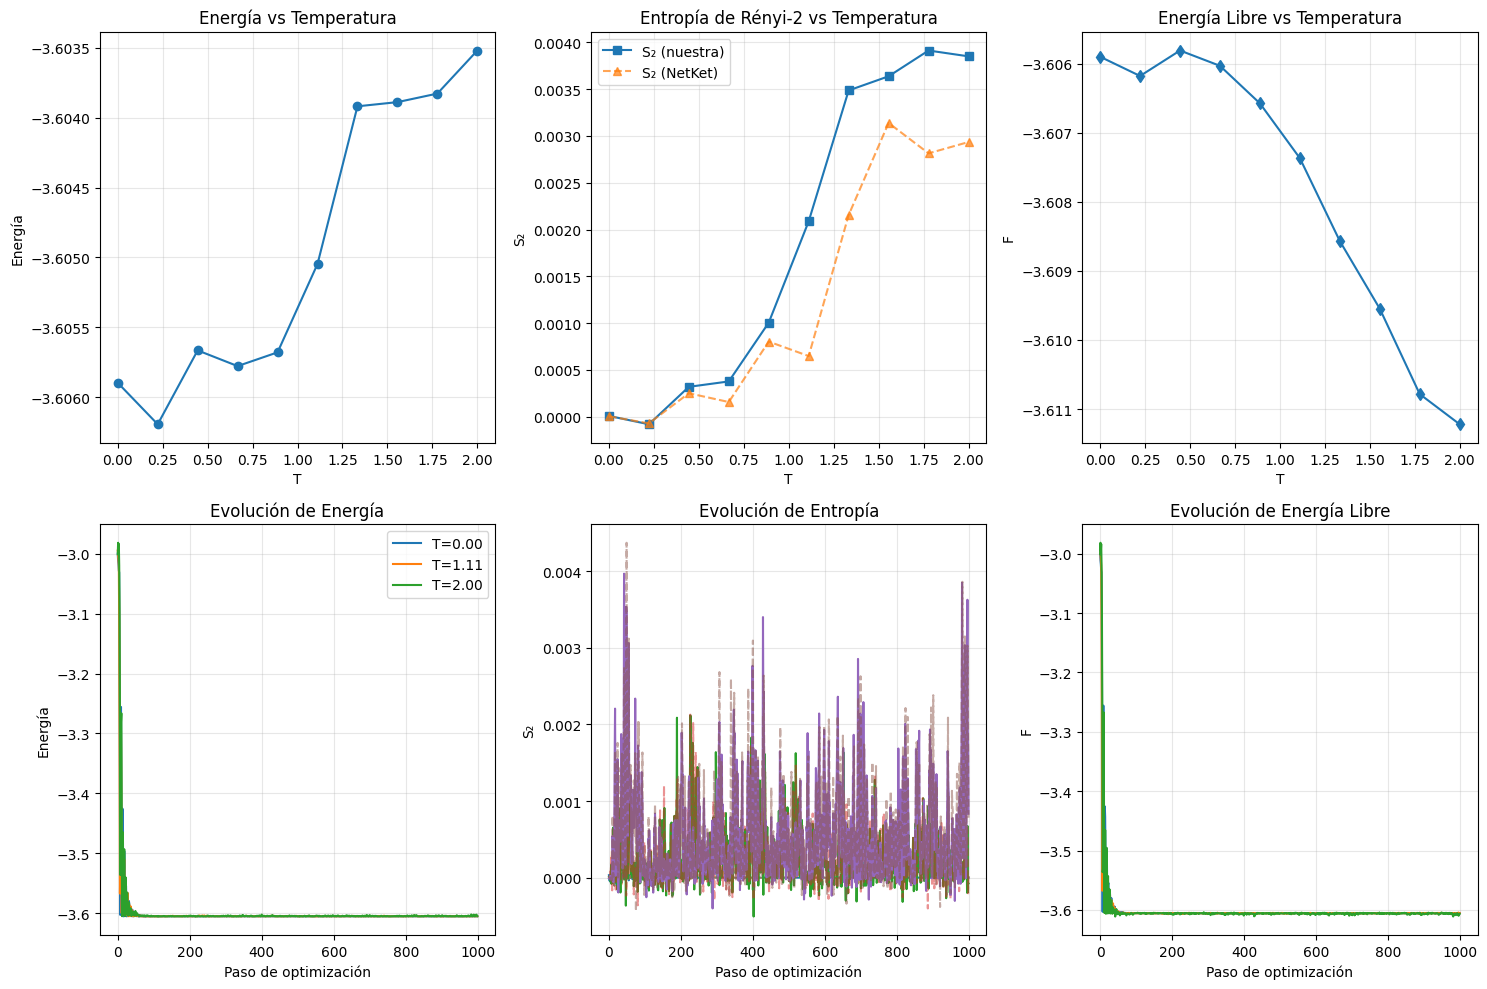


=== RESUMEN DE RESULTADOS ===
Temperatura | Energía | S₂ (nuestra) | S₂ (NetKet) | Energía Libre
----------------------------------------------------------------------
     0.000 |  -3.6059 |       0.0000 |      0.0000 |       -3.6059
     0.222 |  -3.6062 |      -0.0001 |     -0.0001 |       -3.6062
     0.444 |  -3.6057 |       0.0003 |      0.0003 |       -3.6058
     0.667 |  -3.6058 |       0.0004 |      0.0002 |       -3.6060
     0.889 |  -3.6057 |       0.0010 |      0.0008 |       -3.6066
     1.111 |  -3.6050 |       0.0021 |      0.0006 |       -3.6074
     1.333 |  -3.6039 |       0.0035 |      0.0022 |       -3.6086
     1.556 |  -3.6039 |       0.0036 |      0.0031 |       -3.6095
     1.778 |  -3.6038 |       0.0039 |      0.0028 |       -3.6108
     2.000 |  -3.6035 |       0.0039 |      0.0029 |       -3.6112


In [30]:
#Minimizar F = <H> - TS₂ en función de T para comparar con "Ancilla_exact.ipynb"

# g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=4)
sampler = nk.sampler.ExactSampler(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)

T_array = np.linspace(0, 2, 10)  

energy_results = []
entropy_results = []  
entropy_netket_results = []  
free_energy_results = []
all_histories = []

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")
    vstate = nk.vqs.MCState(sampler, model, n_samples=20000)
    optimizer = optax.sgd(learning_rate=0.1, momentum=0.9)
    # optimizer = optax.adam(learning_rate=0.1)
    opt_state = optimizer.init(vstate.parameters)
    
    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended,partition=partition)
    
    energy_history = []
    entropy_history = []
    entropy_netket_history = []
    F_history = []

    best_F = np.inf
    best_energy = None
    best_entropy = None
    best_entropy_netket = None
    best_step = None

    n_steps = 1000
    
    for step in range(n_steps):
        E, E_grad = vstate.expect_and_grad(H_extended)
        
        S2_val, S2_grad = renyi2_entropy_and_grad_sampled(
            vstate, 
            subsystem_sites=partition,
            n_samples=10000,
            key=step 
        )
        S2_netket = vstate.expect(S2_obs).mean.real*np.log(2)
        
        F_grad = jax.tree_util.tree_map(
            lambda grad_E, grad_S2: grad_E - T * grad_S2,
            E_grad, S2_grad
        )
        
        updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)
        
        F = E.mean.real - T * S2_val
        
        energy_history.append(E.mean.real)
        entropy_history.append(S2_val)
        entropy_netket_history.append(S2_netket)
        F_history.append(F)

        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2_val
            best_entropy_netket = S2_netket
            best_step = step

        
        if step % 50 == 0:
            grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
            print(f"  Step {step}: E={E.mean.real:.4f}, S₂={S2_val:.4f}, "
                  f"S₂(NK)={S2_netket:.4f}, F={F:.4f}, |∇F|={grad_norm:.4f}")
    
    final_energy = best_energy
    final_entropy = best_entropy
    final_entropy_netket = best_entropy_netket
    final_F = best_F
    
    energy_results.append(final_energy)
    entropy_results.append(final_entropy)
    entropy_netket_results.append(final_entropy_netket)
    free_energy_results.append(final_F)
    
    all_histories.append({
        'T': T,
        'energy': energy_history,
        'entropy': entropy_history,
        'entropy_netket': entropy_netket_history,
        'free_energy': F_history
    })
    
    print(f"  Mejor resultado: E={final_energy:.4f}, S₂={final_entropy:.4f}, "
          f"F={final_F:.4f}")
    print(f"  Diferencia S₂: {abs(final_entropy - final_entropy_netket):.6f}")

# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.plot(T_array, entropy_netket_results, '^--', label='S₂ (NetKet)', alpha=0.7)
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.plot(hist['entropy_netket'], '--', alpha=0.5)
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.show()

# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (nuestra) | S₂ (NetKet) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | "
          f"{entropy_netket_results[i]:11.4f} | {free_energy_results[i]:13.4f}")

In [ ]:
#Minimizar con optimización bayesiana (skopt)

from skopt import gp_minimize
from skopt.space import Real
from jax.flatten_util import ravel_pytree

g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
vstate.init_parameters()

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

flat_params, unravel_fn = ravel_pytree(vstate.parameters)

def objective(flat_params):
    vstate.parameters = unravel_fn(jnp.array(flat_params))
    E = vstate.expect(H_extended).mean.real
    S2, S2_grad = renyi2_entropy_and_grad_sampled(vstate, partition, 2016)
    # S2 = vstate.expect(S2_obs).mean.real
    F = E - 2 * S2
    # print(f"<H>={E:.2f},  S₂={S2:.2f}, F={F:.2f}")
    return float(F)

# Espacio de búsqueda
space = [Real(-2, 2, name=f"p{i}") for i in range(len(flat_params))]

res = gp_minimize(
    func=objective,
    dimensions=space,
    acq_func="EI",      # Expected Improvement
    n_calls=50,         # número de evaluaciones totales
    n_initial_points=10,
    random_state=42
)

best_params = jnp.array(res.x)
vstate.parameters = unravel_fn(best_params)

print("Best F =", res.fun)
E_best = vstate.expect(H_extended).mean.real
S2_best, _ = renyi2_entropy_and_grad_sampled(vstate, partition, 2016)
print(f"Best E = {E_best:.4f}")
print(f"Best S2 = {S2_best:.4f}")

Best F = -4.061211788767066
Best E = -2.5585
Best S2 = 0.7324


T = 0.00, <H> = -3.24,  S₂= 0.27, F = -3.27
T = 0.22, <H> = -2.75,  S₂= 0.54, F = -2.89
T = 0.44, <H> = -2.86,  S₂= 0.61, F = -3.08
T = 0.67, <H> = -2.67,  S₂= 0.59, F = -3.15
T = 0.89, <H> = -2.92,  S₂= 0.67, F = -3.41
T = 1.11, <H> = -3.14,  S₂= 0.28, F = -3.38
T = 1.33, <H> = -2.78,  S₂= 0.56, F = -3.60
T = 1.56, <H> = -2.58,  S₂= 0.68, F = -3.76
T = 1.78, <H> = -2.68,  S₂= 0.64, F = -3.93
T = 2.00, <H> = -2.95,  S₂= 0.61, F = -4.05


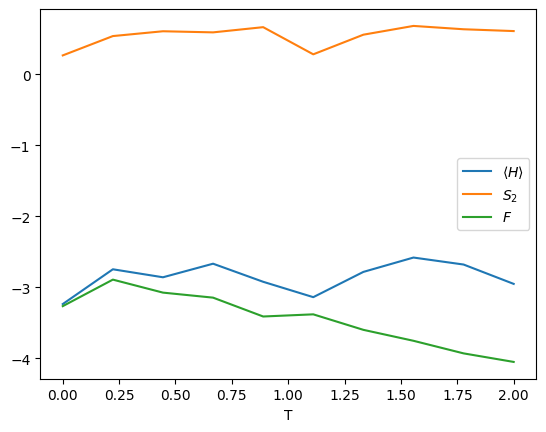

In [20]:
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

T = np.linspace(0,2,10)
H_history = []
S_history = []
F_history = []

for t in T:
    vstate.init_parameters()
    # S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)
    flat_params, unravel_fn = ravel_pytree(vstate.parameters)

    def objective(flat_params):
        vstate.parameters = unravel_fn(jnp.array(flat_params))
        E = vstate.expect(H_extended).mean.real
        S2 = renyi2_entropy_sampled(vstate=vstate, N=N, subsystem_sites=partition, n_samples=2016)
        # S2 = vstate.expect(S2_obs).mean.real
        F = E - t * S2
        return float(F)

    # Espacio de búsqueda
    space = [Real(-2, 2, name=f"p{i}") for i in range(len(flat_params))]

    res = gp_minimize(
        func=objective,
        dimensions=space,
        acq_func="EI",      # Expected Improvement
        n_calls=70,         # número de evaluaciones totales
        n_initial_points=10,
        random_state=42
    )

    best_params = jnp.array(res.x)
    vstate.parameters = unravel_fn(best_params)

    F_best = res.fun
    E_best = vstate.expect(H_extended).mean.real
    S2_best = renyi2_entropy_sampled(vstate=vstate, N=N, subsystem_sites=partition, n_samples=2016)
    print(f"T = {t:.2f}, <H> = {E_best:.2f},  S₂= {S2_best:.2f}, F = {F_best:.2f}")
    F_history.append(F_best)
    H_history.append(E_best)
    S_history.append(S2_best)

plt.plot(T, H_history, label=r"$\langle H \rangle $")
plt.plot(T, S_history, label=r"$S_2$")
plt.plot(T, F_history, label=r"$F$")
plt.xlabel("T")
plt.legend()
plt.show()

Mejor energía libre encontrada: -7.190910
Energía E correspondiente: -1.541171
Entropía S₂ correspondiente: 1.129948


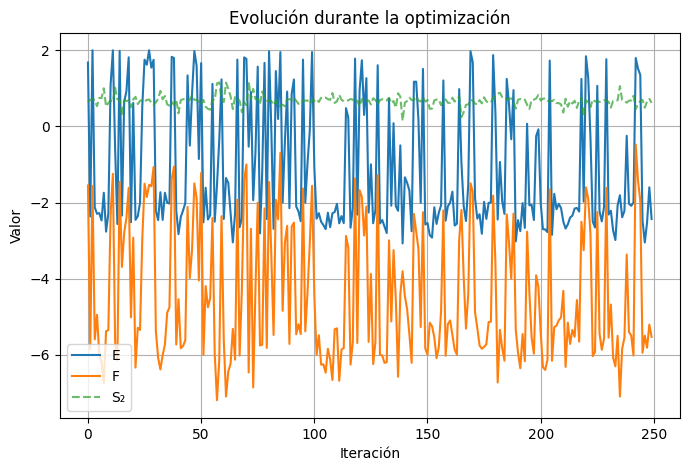

In [21]:
#Minimizar con optimización bayesiana (Optuna)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree

g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
vstate.init_parameters()

# Aplanamos los parámetros iniciales de NetKet
flat_params0, unravel_fn = ravel_pytree(vstate.parameters)

# Diccionario para registrar evolución
history = {"E": [], "S2": [], "F": []}

def make_objective(vstate, H_extended, T):
    def objective(trial):
        # Crear un vector de parámetros propuesto por Optuna
        flat_params = []
        for i in range(len(flat_params0)):
            flat_params.append(trial.suggest_float(f"p{i}", -2.0, 2.0))
        flat_params = jnp.array(flat_params)
        # Asignar parámetros al estado variacional
        vstate.parameters = unravel_fn(flat_params)
        # Calcular observables
        E = vstate.expect(H_extended).mean.real
        S2, grad = renyi2_entropy_and_grad_sampled(vstate=vstate, subsystem_sites=partition, n_samples=2016)
        F = E - T * S2
        # Guardar historia
        history["E"].append(E)
        history["S2"].append(S2)
        history["F"].append(F)
        # Minimizar F
        return float(F)
    return objective

# Crear función objetivo
objective = make_objective(vstate, H_extended, T=5)

study = optuna.create_study(direction="minimize", study_name="FreeEnergyOptimization")
study.optimize(objective, n_trials=250)

best_params = study.best_params
best_flat = jnp.array([best_params[f"p{i}"] for i in range(len(flat_params0))])
vstate.parameters = unravel_fn(best_flat)

print(f"Mejor energía libre encontrada: {study.best_value:.6f}")
print(f"Energía E correspondiente: {history['E'][study.best_trial.number]:.6f}")
print(f"Entropía S₂ correspondiente: {history['S2'][study.best_trial.number]:.6f}")
plt.figure(figsize=(8,5))
plt.plot(history["E"], label="E")
plt.plot(history["F"], label="F")
plt.plot(history["S2"], label="S₂", linestyle="--", alpha=0.7)
plt.xlabel("Iteración")
plt.ylabel("Valor")
plt.legend()
plt.title("Evolución durante la optimización")
plt.grid(True)
plt.show()

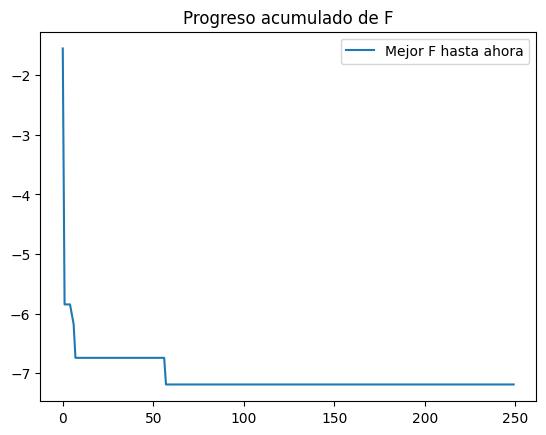

In [22]:
best_so_far = [min(history["F"][:i+1]) for i in range(len(history["F"]))]
plt.plot(best_so_far, label="Mejor F hasta ahora")
plt.legend()
plt.title("Progreso acumulado de F")
plt.show()


In [23]:
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()
vis.plot_slice(study).show()


T = 0.00, <H> = -3.55,  S₂= 0.01, F = -3.55
T = 0.22, <H> = -3.51,  S₂= 0.10, F = -3.53
T = 0.44, <H> = -3.57,  S₂= 0.03, F = -3.59
T = 0.67, <H> = -3.24,  S₂= 0.35, F = -3.47
T = 0.89, <H> = -3.26,  S₂= 0.42, F = -3.63
T = 1.11, <H> = -3.12,  S₂= 0.56, F = -3.74
T = 1.33, <H> = -3.00,  S₂= 0.61, F = -3.82
T = 1.56, <H> = -3.02,  S₂= 0.58, F = -3.93
T = 1.78, <H> = -3.02,  S₂= 0.64, F = -4.15
T = 2.00, <H> = -2.96,  S₂= 0.66, F = -4.28


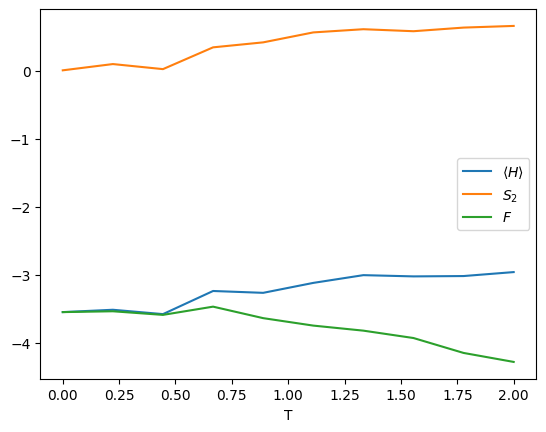

In [24]:
T = np.linspace(0,2,10)
H_history = []
S_history = []
F_history = []

for t in T: 
    sampler = nk.sampler.MetropolisLocal(hi_extended)
    model = RBM_Z2(alpha=1, trivial_Z2=True)
    vstate = nk.vqs.MCState(sampler, model, n_samples=10000)
    vstate.init_parameters()
    # Aplanamos los parámetros iniciales de NetKet
    flat_params0, unravel_fn = ravel_pytree(vstate.parameters)
    # Diccionario para registrar evolución
    history = {"E": [], "S2": [], "F": []}

    def make_objective(vstate, H_extended, T):
        def objective(trial):
            # Crear un vector de parámetros propuesto por Optuna
            flat_params = []
            for i in range(len(flat_params0)):
                flat_params.append(trial.suggest_float(f"p{i}", -2.0, 2.0))
            flat_params = jnp.array(flat_params)
            # Asignar parámetros al estado variacional
            vstate.parameters = unravel_fn(flat_params)
            # Calcular observables
            E = vstate.expect(H_extended).mean.real
            S2 = renyi2_entropy_sampled(vstate, N, partition, 20000)
            F = E - T * S2
            # Guardar historia
            history["E"].append(E)
            history["S2"].append(S2)
            history["F"].append(F)
            # Minimizar F
            return float(F)
        return objective

    # Crear función objetivo
    objective = make_objective(vstate, H_extended, T=t)

    study = optuna.create_study(direction="minimize", study_name="FreeEnergyOptimization")
    study.optimize(objective, n_trials=400)

    best_params = study.best_params
    best_flat = jnp.array([best_params[f"p{i}"] for i in range(len(flat_params0))])
    vstate.parameters = unravel_fn(best_flat)

    F_best = study.best_value
    E_best = history['E'][study.best_trial.number]
    S2_best = history['S2'][study.best_trial.number]
    print(f"T = {t:.2f}, <H> = {E_best:.2f},  S₂= {S2_best:.2f}, F = {F_best:.2f}")
    F_history.append(F_best)
    H_history.append(E_best)
    S_history.append(S2_best)

plt.plot(T, H_history, label=r"$\langle H \rangle $")
plt.plot(T, S_history, label=r"$S_2$")
plt.plot(T, F_history, label=r"$F$")
plt.xlabel("T")
plt.legend()
plt.show()

In [25]:
samples = vstate.sample(n_samples=16)
print("Configuraciones muestreadas:", samples[0:10])

Configuraciones muestreadas: [[[ 1  1  1 -1]]

 [[ 1 -1  1 -1]]

 [[ 1 -1 -1  1]]

 [[ 1  1 -1 -1]]

 [[ 1  1 -1 -1]]

 [[-1 -1 -1  1]]

 [[-1 -1 -1  1]]

 [[ 1  1 -1 -1]]

 [[-1 -1 -1  1]]

 [[-1 -1 -1  1]]]
